Step 1: Load & Inspect the Dataset

In [274]:
import pandas as pd

df = pd.read_csv('credit_risk_dataset.csv')

print("Shape:", df.shape)
print("\nColumns & Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df['loan_status'].value_counts())
print("\nSample rows:\n", df.head(3))

Shape: (32581, 12)

Columns & Types:
 person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Missing Values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Target Distribution:
 loan_status
0    2

Step 2: Handle Missing Values

In [275]:
from sklearn.impute import SimpleImputer

numerical_cols   = ['person_age', 'person_income', 'person_emp_length',
                    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
                    'cb_person_cred_hist_length']

categorical_cols = ['person_home_ownership', 'loan_intent',
                    'loan_grade', 'cb_person_default_on_file']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[numerical_cols]   = num_imputer.fit_transform(df[numerical_cols])
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("Missing after imputation:\n", df.isnull().sum())

Missing after imputation:
 person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


Step 3: Encode Categorical Columns

In [276]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded '{col}': {le.classes_.tolist()}")

Encoded 'person_home_ownership': ['MORTGAGE', 'OTHER', 'OWN', 'RENT']
Encoded 'loan_intent': ['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']
Encoded 'loan_grade': ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Encoded 'cb_person_default_on_file': ['N', 'Y']


Step 4: Scale Numerical Features

In [277]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Numerical features after scaling:")
print(df[numerical_cols].describe().round(2))

Numerical features after scaling:
       person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
count    32581.00       32581.00           32581.00   32581.00       32581.00   
mean         0.00           0.00               0.00      -0.00          -0.00   
std          1.00           1.00               1.00       1.00           1.00   
min         -1.22          -1.00              -1.17      -1.44          -1.81   
25%         -0.75          -0.44              -0.68      -0.73          -0.82   
50%         -0.27          -0.18              -0.19      -0.25          -0.01   
75%          0.36           0.21               0.55       0.41           0.68   
max         18.32          95.74              28.93       4.02           3.96   

       loan_percent_income  cb_person_cred_hist_length  
count             32581.00                    32581.00  
mean                  0.00                       -0.00  
std                   1.00                        1.00  
min     

Step 5: Separate Features & Target

In [278]:
import numpy as np

feature_names = numerical_cols + categorical_cols

X = df[feature_names].values.astype(np.float32)
y = df['loan_status'].values.astype(np.float32)

print("X shape:", X.shape)   # (32581, 11)
print("y shape:", y.shape)   # (32581,)

X shape: (32581, 11)
y shape: (32581,)


Step 6: Train / Test Split

In [279]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)   # (26064, 11)
print("X_test :", X_test.shape)    # (6517, 11)
print("y_train defaults:", int(y_train.sum()))
print("y_test  defaults:", int(y_test.sum()))

X_train: (26064, 11)
X_test : (6517, 11)
y_train defaults: 5686
y_test  defaults: 1422


Step 7: Reshape for Sequence Models

In [280]:
# Shape: (samples, timesteps=1, features=11)
X_train_seq = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_seq  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

print("Sequence shape for GRU/Transformer:", X_train_seq.shape)
# (26064, 1, 11)

Sequence shape for GRU/Transformer: (26064, 1, 11)


Step 8: Build & Train the GRU Model

In [281]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

# ── Reproducibility ──────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)

# ── Class weight (handles 78/22 imbalance) ───────────────────
from sklearn.utils import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight = dict(enumerate(class_weights_array))

print("Class weights:", class_weight)

# — Build GRU Model ————————————————————————————
inputs = tf.keras.Input(shape=(1, 11), name='input')         # (batch, 1, 11)

x = layers.GRU(64, return_sequences=False, name='gru_1')(inputs)
x = layers.Dropout(0.3, name='dropout_1')(x)
x = layers.Dense(256, activation='relu', name='hidden_1')(x)  # hidden layer 1
x = layers.Dropout(0.3, name='dropout_2')(x)
x = layers.Dense(128, activation='relu', name='hidden_2')(x)  # hidden layer 2
x = layers.Dropout(0.3, name='dropout_3')(x)
x = layers.Dense(64, activation='relu', name='hidden_3')(x)   # hidden layer 3
x = layers.Dropout(0.2, name='dropout_4')(x)
x = layers.Dense(32, activation='relu', name='last_hidden')(x) # hidden layer 4 ← SHAP target layer
x = layers.Dropout(0.2, name='dropout_5')(x)
output = layers.Dense(1, activation='sigmoid', name='output')(x)

gru_model = Model(inputs, output, name='GRU_CreditRisk')
gru_model.summary()

Class weights: {0: np.float64(0.6395132005103543), 1: np.float64(2.291945128385508)}


Model: "GRU_CreditRisk"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        14,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_hidden (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,689 (291.75 KB)

 Trainable params: 74,689 (291.75 KB)

 Non-trainable params: 0 (0.00 B)

Compile & Train:

In [282]:
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)

history_gru = gru_model.fit(
    X_train_seq, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7101 - loss: 0.5548 - val_accuracy: 0.7633 - val_loss: 0.4826
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7877 - loss: 0.4847 - val_accuracy: 0.8036 - val_loss: 0.4389
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8056 - loss: 0.4664 - val_accuracy: 0.8082 - val_loss: 0.4203
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8164 - loss: 0.4550 - val_accuracy: 0.8189 - val_loss: 0.4085
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8187 - loss: 0.4477 - val_accuracy: 0.8243 - val_loss: 0.3939
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8264 - loss: 0.4399 - val_accuracy: 0.8347 - val_loss: 0.3864
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8277 - loss: 0.4355 - val_accuracy: 0.8504 - val_loss: 0.3660
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8340 - loss: 0.4269 - val_accuracy: 0.8542 - val_loss:

Evaluate GRU:

In [283]:
y_pred_prob_gru = gru_model.predict(X_test_seq).flatten()
y_pred_gru      = (y_pred_prob_gru >= 0.5).astype(int)

acc_gru = accuracy_score(y_test, y_pred_gru)
auc_gru = roc_auc_score(y_test, y_pred_prob_gru)

print(f"GRU  →  Accuracy: {acc_gru:.4f}  |  AUC: {auc_gru:.4f}")

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
GRU  →  Accuracy: 0.8683  |  AUC: 0.8986


Step 9: Build & Train the Transformer Model

In [284]:
# ── Transformer Encoder Block ────────────────────────────────
def transformer_encoder(inputs, head_size=32, num_heads=4, ff_dim=64, dropout=0.3):
    # Multi-Head Self Attention
    x = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size, name='mha_1'
    )(inputs, inputs)
    x = layers.Dropout(dropout, name='drop_attn')(x)
    x = layers.LayerNormalization(epsilon=1e-6, name='norm_1')(x + inputs)  # residual

    # Feed-Forward block
    ff = layers.Dense(ff_dim, activation='relu', name='ff_dense_1')(x)
    ff = layers.Dropout(dropout, name='drop_ff')(ff)
    ff = layers.Dense(inputs.shape[-1], name='ff_dense_2')(ff)
    x  = layers.LayerNormalization(epsilon=1e-6, name='norm_2')(x + ff)     # residual
    return x

# — Build Transformer Model ————————————————————
inputs_t = tf.keras.Input(shape=(1, 11), name='input')

x = transformer_encoder(inputs_t)                                        # (batch, 1, 11)
x = layers.GlobalAveragePooling1D(name='gap')(x) 
x = layers.Dense(256, activation='relu', name='hidden_1')(x)             # hidden layer 1
x = layers.Dropout(0.3, name='dropout_1')(x)                        # (batch, 11)
x = layers.Dense(128, activation='relu', name='hidden_2')(x)             # hidden layer 2
x = layers.Dropout(0.3, name='dropout_2')(x)
x = layers.Dense(64, activation='relu', name='hidden_3')(x)              # hidden layer 3
x = layers.Dropout(0.2, name='dropout_3')(x)
x = layers.Dense(32, activation='relu', name='last_hidden')(x)           # hidden layer 4 ← SHAP target layer
x = layers.Dropout(0.2, name='dropout_final')(x)
output_t = layers.Dense(1, activation='sigmoid', name='output')(x)

transformer_model = Model(inputs_t, output_t, name='Transformer_CreditRisk')
transformer_model.summary()

Model: "Transformer_CreditRisk"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 1, 11)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_1               │ (None, 1, 11)     │      6,027 │ input[0][0],      │
│ (MultiHeadAttentio… │                   │            │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_attn (Dropout) │ (None, 1, 11)     │          0 │ mha_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 1, 11)     │          0 │ drop_attn[0][0],  │
│                     │                   │            │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ norm_1              │ (None, 1, 11)     │         22 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_dense_1 (Dense)  │ (None, 1, 64)     │        768 │ norm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_ff (Dropout)   │ (None, 1, 64)     │          0 │ ff_dense_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_dense_2 (Dense)  │ (None, 1, 11)     │        715 │ drop_ff[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 1, 11)     │          0 │ norm_1[0][0],     │
│                     │                   │            │ ff_dense_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ norm_2              │ (None, 1, 11)     │         22 │ add_15[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 11)        │          0 │ norm_2[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_1 (Dense)    │ (None, 256)       │      3,072 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ hidden_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_2 (Dense)    │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ hidden_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hidden_3 (Dense)    │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ hidden_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ last_hidden (Dense) │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_final       │ (None, 32)        │          0 │ last_hidden[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_final[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,891 (210.51 KB)

 Trainable params: 53,891 (210.51 KB)

 Non-trainable params: 0 (0.00 B)

Compile & Train:

In [285]:
transformer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_t = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)

history_transformer = transformer_model.fit(
    X_train_seq, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop_t],
    verbose=1
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7345 - loss: 0.5531 - val_accuracy: 0.7883 - val_loss: 0.4654
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7893 - loss: 0.4969 - val_accuracy: 0.7825 - val_loss: 0.4818
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8053 - loss: 0.4812 - val_accuracy: 0.8205 - val_loss: 0.4319
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8137 - loss: 0.4683 - val_accuracy: 0.8170 - val_loss: 0.4259
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8135 - loss: 0.4608 - val_accuracy: 0.8305 - val_loss: 0.4109
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8264 - loss: 0.4500 - val_accuracy: 0.8182 - val_loss: 0.4260
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8263 - loss: 0.4467 - val_accuracy: 0.8301 - val_loss: 0.4002
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8312 - loss: 0.4398 - val_accuracy: 0.8493 - v

Evaluate Transformer:

In [286]:
y_pred_prob_tr = transformer_model.predict(X_test_seq).flatten()
y_pred_tr      = (y_pred_prob_tr >= 0.5).astype(int)

acc_tr = accuracy_score(y_test, y_pred_tr)
auc_tr = roc_auc_score(y_test, y_pred_prob_tr)

print(f"Transformer  →  Accuracy: {acc_tr:.4f}  |  AUC: {auc_tr:.4f}")

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Transformer  →  Accuracy: 0.8587  |  AUC: 0.8911


Step 10: Build & Train the CapsuleNet Model

In [287]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np

# ── Squash Activation (Capsule-specific) ─────────────────────
# Squash keeps direction but scales magnitude to (0,1)
def squash(vectors, axis=-1):
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis=axis, keepdims=True)
    scale = s_squared_norm / (1 + s_squared_norm) / tf.sqrt(s_squared_norm + 1e-9)
    return scale * vectors

# ── Capsule Layer with Dynamic Routing ───────────────────────
class CapsuleLayer(layers.Layer):
    def __init__(self, num_capsules, dim_capsule, num_routing=3, **kwargs):
        super().__init__(**kwargs)
        self.num_capsules = num_capsules
        self.dim_capsule  = dim_capsule
        self.num_routing  = num_routing

    def build(self, input_shape):
        self.input_num_capsules = input_shape[1]
        self.input_dim_capsule  = input_shape[2]
        self.W = self.add_weight(
            shape=(self.input_num_capsules, self.num_capsules,
                   self.input_dim_capsule, self.dim_capsule),
            initializer='glorot_uniform', trainable=True, name='W'
        )

    def call(self, inputs):
        # inputs: (batch, input_caps, input_dim)
        inputs_expand = tf.expand_dims(tf.expand_dims(inputs, 2), 4)
        # W: (input_caps, num_caps, input_dim, dim_cap)
        W_tiled = tf.tile(tf.expand_dims(self.W, 0),
                          [tf.shape(inputs)[0], 1, 1, 1, 1])
        inputs_tiled = tf.tile(inputs_expand,
                               [1, 1, self.num_capsules, 1, 1])
        u_hat = tf.squeeze(tf.matmul(W_tiled, inputs_tiled), axis=4)
        # u_hat: (batch, input_caps, num_caps, dim_cap)

        b = tf.zeros([tf.shape(inputs)[0],
                      self.input_num_capsules,
                      self.num_capsules, 1])

        for i in range(self.num_routing):
            c = tf.nn.softmax(b, axis=2)              # routing weights
            s = tf.reduce_sum(c * u_hat, axis=1)      # weighted sum
            v = squash(s)                              # squash
            if i < self.num_routing - 1:
                b += tf.reduce_sum(
                    u_hat * tf.expand_dims(v, 1), axis=-1, keepdims=True)
        return v   # (batch, num_capsules, dim_capsule)

# ── Length Layer (capsule magnitude → probability) ───────────
class Length(layers.Layer):
    def call(self, inputs):
        return tf.sqrt(tf.reduce_sum(tf.square(inputs), axis=-1) + 1e-9)

Build the Model:

In [288]:
# — Build CapsuleNet Model ————————————————————
inputs_c = tf.keras.Input(shape=(1, 11), name='input')

# Flatten input
x = layers.Flatten(name='flatten')(inputs_c)                              # (batch, 11)

# Hidden layer 1
x = layers.Dense(256, activation='relu', name='hidden_1')(x)             # hidden layer 1
x = layers.Dropout(0.3, name='dropout_1')(x)

# Hidden layer 2
x = layers.Dense(128, activation='relu', name='hidden_2')(x)             # hidden layer 2
x = layers.Dropout(0.3, name='dropout_2')(x)

# Hidden layer 3
x = layers.Dense(64, activation='relu', name='hidden_3')(x)              # hidden layer 3
x = layers.Dropout(0.2, name='dropout_3')(x)

# Hidden layer 4
x = layers.Dense(32,  activation='relu', name='hidden_4')(x)   # ← new Dense(32) hidden layer 4
x = layers.Dropout(0.2, name='dropout_4')(x)

# Reshape into primary capsules
x = layers.Dense(128, activation='relu', name='embedding')(x)            # (batch, 128)
x = layers.Dropout(0.3, name='dropout_5')(x)
x = layers.Reshape((8, 16), name='primary_caps')(x)                      # (batch, 8, 16)
x = layers.Lambda(squash, name='squash_1')(x)

# Credit capsules ← SHAP target layer (capsule level)
caps_output = CapsuleLayer(
    num_capsules=2, dim_capsule=16,
    num_routing=3, name='credit_caps'
)(x)                                                                      # (batch, 2, 16)

# Flatten capsule output as last hidden representation
last_hidden = layers.Reshape((32,), name='last_hidden')(caps_output)     # (batch, 32)

# Final output
lengths  = Length(name='output_length')(caps_output)                     # (batch, 2)
output_c = layers.Lambda(lambda t: t[:, 1], name='output')(lengths)     # (batch,) → prob of default
output_c = layers.Reshape((1,), name='output_reshape')(output_c)

capsnet_model = Model(inputs_c, output_c, name='CapsuleNet_CreditRisk')
capsnet_model.summary()

Model: "CapsuleNet_CreditRisk"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1, 11)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ primary_caps (Reshape)          │ (None, 8, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ squash_1 (Lambda)               │ (None, 8, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ credit_caps (CapsuleLayer)      │ (None, 2, 16)          │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_length (Length)          │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Lambda)                 │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_reshape (Reshape)        │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,624 (213.38 KB)

 Trainable params: 54,624 (213.38 KB)

 Non-trainable params: 0 (0.00 B)

Compile & Train:

In [289]:
capsnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_c = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)

history_capsnet = capsnet_model.fit(
    X_train_seq, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=256,
    class_weight=class_weight,
    callbacks=[early_stop_c],
    verbose=1
)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.5647 - loss: 0.7367 - val_accuracy: 0.6506 - val_loss: 0.5740
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.7418 - loss: 0.5299 - val_accuracy: 0.7768 - val_loss: 0.4865
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.7851 - loss: 0.4909 - val_accuracy: 0.8209 - val_loss: 0.4103
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8009 - loss: 0.4723 - val_accuracy: 0.8466 - val_loss: 0.3800
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8163 - loss: 0.4553 - val_accuracy: 0.8554 - val_loss: 0.3607
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8152 - loss: 0.4494 - val_accuracy: 0.8512 - val_loss: 0.3666
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8238 - loss: 0.4390 - val_accuracy: 0.8542 - val_loss: 0.3594
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8331 - loss: 0.4292 - val_accuracy: 0.8646 - v

Evaluate CapsuleNet:

In [290]:
y_pred_prob_cap = capsnet_model.predict(X_test_seq).flatten()
y_pred_cap      = (y_pred_prob_cap >= 0.5).astype(int)

acc_cap = accuracy_score(y_test, y_pred_cap)
auc_cap = roc_auc_score(y_test, y_pred_cap)

print(f"CapsuleNet  →  Accuracy: {acc_cap:.4f}  |  AUC: {auc_cap:.4f}")

204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
CapsuleNet  →  Accuracy: 0.8964  |  AUC: 0.8237


Step 11: Full Model SHAP (Output Level)

In [291]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# ── Use a background sample (100 random training samples) ────
# GradientExplainer needs a background dataset to compute
# expected gradients against
background = X_train_seq[:100]

# ── SHAP for GRU ─────────────────────────────────────────────
explainer_gru = shap.GradientExplainer(gru_model, background)
shap_values_gru = explainer_gru.shap_values(X_test_seq[:200])
# shape: (200, 1, 11) → squeeze timestep dimension
shap_gru = np.array(shap_values_gru).squeeze()  # (200, 11)

print("GRU SHAP shape:", shap_gru.shape)

c:\Users\suyog\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=['Tensor(shape=(200, 1, 11))']
  warnings.warn(msg)
c:\Users\suyog\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input
Received: inputs=['Tensor(shape=(50, 1, 11))']
  warnings.warn(msg)


GRU SHAP shape: (200, 11)


In [292]:
# ── SHAP for Transformer ──────────────────────────────────────
explainer_tr = shap.GradientExplainer(transformer_model, background)
shap_values_tr = explainer_tr.shap_values(X_test_seq[:200])
shap_tr = np.array(shap_values_tr).squeeze()  # (200, 11)

print("Transformer SHAP shape:", shap_tr.shape)

Transformer SHAP shape: (200, 11)


In [293]:
# ── SHAP for CapsuleNet ───────────────────────────────────────
explainer_cap = shap.GradientExplainer(capsnet_model, background)
shap_values_cap = explainer_cap.shap_values(X_test_seq[:200])
shap_cap = np.array(shap_values_cap).squeeze()  # (200, 11)

print("CapsuleNet SHAP shape:", shap_cap.shape)

CapsuleNet SHAP shape: (200, 11)


Visualise — SHAP Summary Plots:

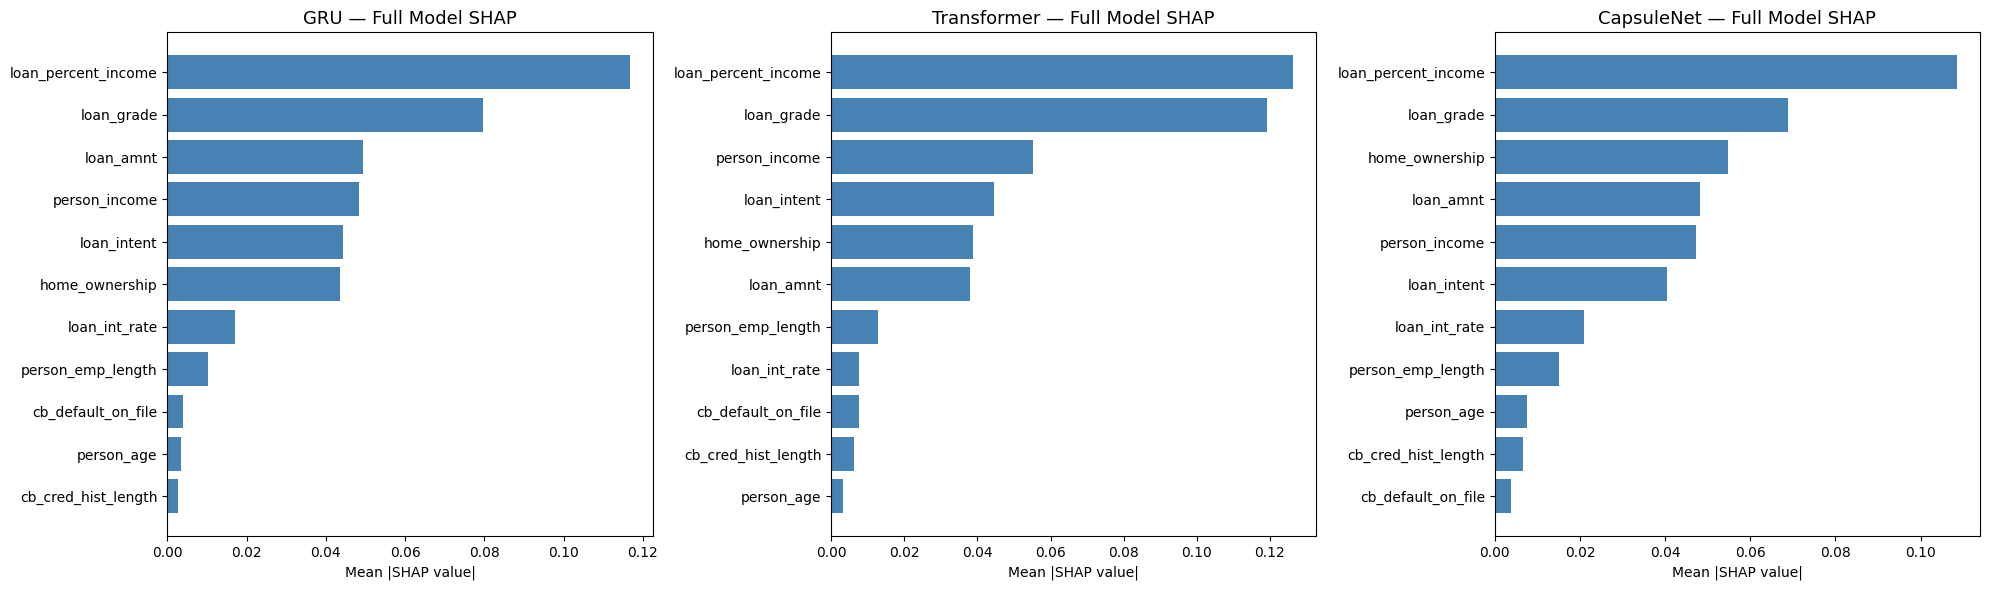

Saved: shap_full_model.png


In [294]:
feature_names_list = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_cred_hist_length', 'home_ownership', 'loan_intent',
    'loan_grade', 'cb_default_on_file'
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, shap_vals, title in zip(
    axes,
    [shap_gru, shap_tr, shap_cap],
    ['GRU', 'Transformer', 'CapsuleNet']
):
    # Mean absolute SHAP per feature
    mean_shap = np.abs(shap_vals).mean(axis=0)
    sorted_idx = np.argsort(mean_shap)[::-1]

    ax.barh(
        [feature_names_list[i] for i in sorted_idx],
        mean_shap[sorted_idx],
        color='steelblue'
    )
    ax.set_title(f'{title} — Full Model SHAP', fontsize=13)
    ax.set_xlabel('Mean |SHAP value|')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('shap_full_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_full_model.png")

Part A: Extract Last Hidden Layer Sub-Models

In [295]:
import tensorflow as tf
import numpy as np
import shap
import matplotlib.pyplot as plt

# ── GRU: last_hidden layer ────────────────────────────────────
gru_hidden_model = tf.keras.Model(
    inputs=gru_model.input,
    outputs=gru_model.get_layer('hidden_3').output
)

# ── Transformer: last_hidden layer ───────────────────────────
tr_hidden_model = tf.keras.Model(
    inputs=transformer_model.input,
    outputs=transformer_model.get_layer('hidden_3').output
)

# ── CapsuleNet: hidden_3 layer ← change name here to switch layer
cap_hidden_model = tf.keras.Model(
    inputs=capsnet_model.input,
    outputs=capsnet_model.get_layer('hidden_3').output      # (batch, 64)
)

# ── Verify shapes ─────────────────────────────────────────────
print("GRU hidden output shape:",
      gru_hidden_model.predict(X_test_seq[:5]).shape)   # (5, 32)
print("Transformer hidden output shape:",
      tr_hidden_model.predict(X_test_seq[:5]).shape)    # (5, 32)
print("CapsuleNet hidden output shape:",
      cap_hidden_model.predict(X_test_seq[:5]).shape)   # (5, 32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
GRU hidden output shape: (5, 64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Transformer hidden output shape: (5, 64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
CapsuleNet hidden output shape: (5, 64)


Part B: Find Top Neurons by Activation Variance

In [296]:
# ── Get hidden activations for all test samples ───────────────
N_SAMPLES = 200   # use 200 test samples for SHAP (speed vs coverage)

gru_acts  = gru_hidden_model.predict(X_test_seq[:N_SAMPLES])   # (200, 32)
tr_acts   = tr_hidden_model.predict(X_test_seq[:N_SAMPLES])    # (200, 32)
cap_acts  = cap_hidden_model.predict(X_test_seq[:N_SAMPLES])   # (200, 32)

# ── Pick top 6 neurons with highest activation variance ───────
# High variance = neuron is actually differentiating between samples
TOP_N = 6

top_gru_neurons  = np.argsort(gru_acts.var(axis=0))[::-1][:TOP_N]
top_tr_neurons   = np.argsort(tr_acts.var(axis=0))[::-1][:TOP_N]
top_cap_neurons  = np.argsort(cap_acts.var(axis=0))[::-1][:TOP_N]

print("Top GRU neuron indices:", top_gru_neurons)
print("Top Transformer neuron indices:", top_tr_neurons)
print("Top CapsuleNet neuron indices:", top_cap_neurons)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Top GRU neuron indices: [16 55 45 24 46  3]
Top Transformer neuron indices: [39 40 38 43 60 15]
Top CapsuleNet neuron indices: [43 24 40 18 56 34]


Part C: SHAP on Each Neuron Slice

In [297]:
# ── Background for GradientExplainer ─────────────────────────
background = X_train_seq[:100]

feature_names_list = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_cred_hist_length', 'home_ownership', 'loan_intent',
    'loan_grade', 'cb_default_on_file'
]

def get_neuron_shap(hidden_model, full_model, top_neurons, samples):
    """
    For each top neuron, build a sub-model that outputs
    just that neuron's activation, then compute SHAP.
    Returns dict: {neuron_idx: shap_array (N_SAMPLES, 11)}
    """
    neuron_shap = {}
    for n_idx in top_neurons:
        # Sub-model → single neuron output
        neuron_output = tf.keras.layers.Lambda(
            lambda x, i=n_idx: x[:, i:i+1]
        )(hidden_model.output)

        neuron_model = tf.keras.Model(
            inputs=full_model.input,
            outputs=neuron_output
        )

        explainer = shap.GradientExplainer(neuron_model, background)
        sv = explainer.shap_values(samples)
        # sv shape: (N_SAMPLES, 1, 11) → squeeze
        neuron_shap[n_idx] = np.array(sv).squeeze()
        print(f"  Neuron {n_idx} done, SHAP shape: {neuron_shap[n_idx].shape}")
    return neuron_shap

print("\nComputing GRU neuron SHAP...")
gru_neuron_shap = get_neuron_shap(
    gru_hidden_model, gru_model,
    top_gru_neurons, X_test_seq[:N_SAMPLES]
)

print("\nComputing Transformer neuron SHAP...")
tr_neuron_shap = get_neuron_shap(
    tr_hidden_model, transformer_model,
    top_tr_neurons, X_test_seq[:N_SAMPLES]
)

print("\nComputing CapsuleNet neuron SHAP...")
cap_neuron_shap = get_neuron_shap(
    cap_hidden_model, capsnet_model,
    top_cap_neurons, X_test_seq[:N_SAMPLES]
)

print("\nAll neuron SHAP values computed!")


Computing GRU neuron SHAP...
  Neuron 16 done, SHAP shape: (200, 11)
  Neuron 55 done, SHAP shape: (200, 11)
  Neuron 45 done, SHAP shape: (200, 11)
  Neuron 24 done, SHAP shape: (200, 11)
  Neuron 46 done, SHAP shape: (200, 11)
  Neuron 3 done, SHAP shape: (200, 11)

Computing Transformer neuron SHAP...
  Neuron 39 done, SHAP shape: (200, 11)
  Neuron 40 done, SHAP shape: (200, 11)
  Neuron 38 done, SHAP shape: (200, 11)
  Neuron 43 done, SHAP shape: (200, 11)
  Neuron 60 done, SHAP shape: (200, 11)
  Neuron 15 done, SHAP shape: (200, 11)

Computing CapsuleNet neuron SHAP...
  Neuron 43 done, SHAP shape: (200, 11)
  Neuron 24 done, SHAP shape: (200, 11)
  Neuron 40 done, SHAP shape: (200, 11)
  Neuron 18 done, SHAP shape: (200, 11)
  Neuron 56 done, SHAP shape: (200, 11)
  Neuron 34 done, SHAP shape: (200, 11)

All neuron SHAP values computed!


Part D: Visualise Neuron-Slice SHAP

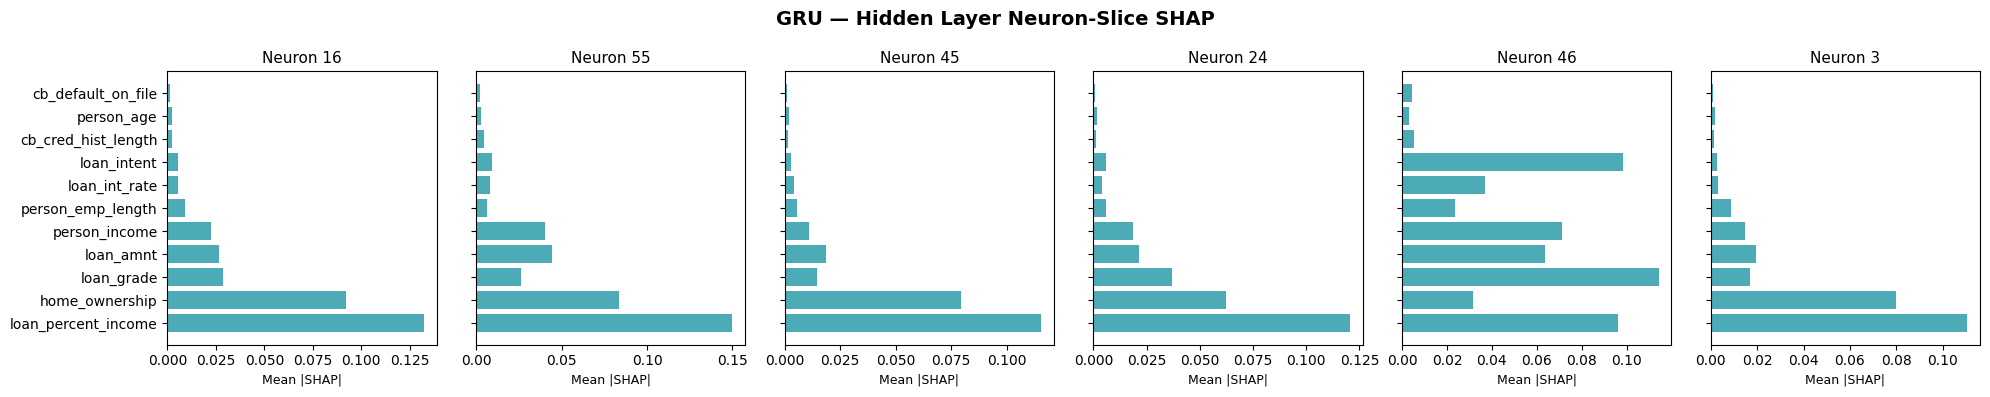

Saved: shap_neuron_gru.png


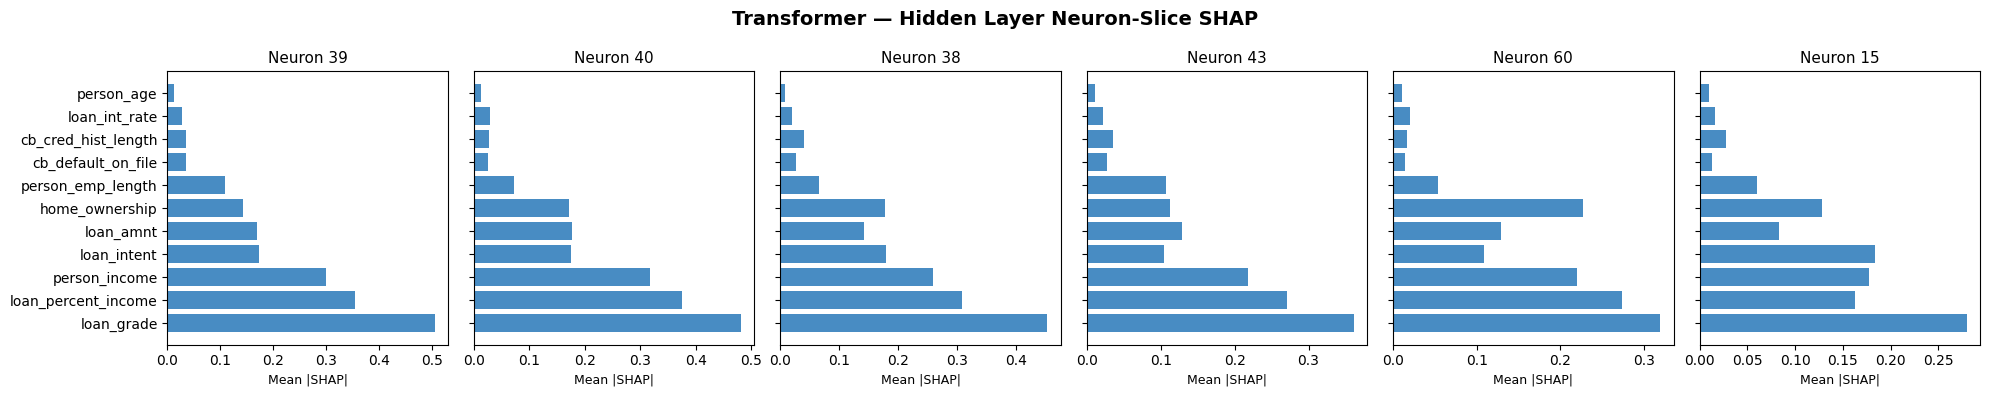

Saved: shap_neuron_transformer.png


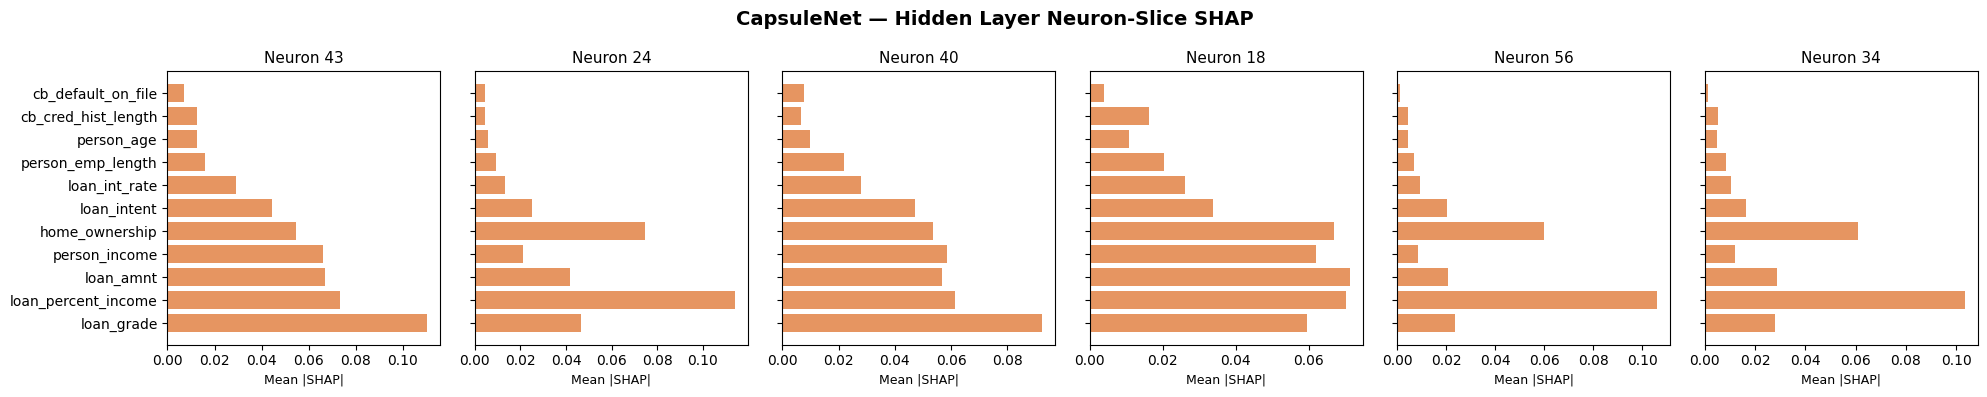

Saved: shap_neuron_capsulenet.png


In [298]:
def plot_neuron_shap(neuron_shap_dict, top_neurons,
                     model_name, feature_names, color):
    fig, axes = plt.subplots(1, TOP_N, figsize=(20, 4), sharey=True)
    fig.suptitle(f'{model_name} — Hidden Layer Neuron-Slice SHAP',
                 fontsize=14, fontweight='bold')

    for ax, n_idx in zip(axes, top_neurons):
        sv = neuron_shap_dict[n_idx]           # (200, 11)
        mean_abs = np.abs(sv).mean(axis=0)     # (11,)
        sorted_idx = np.argsort(mean_abs)[::-1]

        ax.barh(
            [feature_names[i] for i in sorted_idx],
            mean_abs[sorted_idx],
            color=color, alpha=0.8
        )
        ax.set_title(f'Neuron {n_idx}', fontsize=11)
        ax.set_xlabel('Mean |SHAP|', fontsize=9)
        ax.invert_yaxis()

    plt.tight_layout()
    fname = f'shap_neuron_{model_name.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

# ── Plot all three models ─────────────────────────────────────
plot_neuron_shap(gru_neuron_shap,  top_gru_neurons,
                 'GRU',         feature_names_list, '#2196a6')

plot_neuron_shap(tr_neuron_shap,   top_tr_neurons,
                 'Transformer', feature_names_list, '#1a6fb5')

plot_neuron_shap(cap_neuron_shap,  top_cap_neurons,
                 'CapsuleNet',  feature_names_list, '#e07b39')

Step 13: Permutation Feature Importance

Part A: Compute Permutation Importance for All 3 Models

In [299]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

feature_names_list = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_cred_hist_length', 'home_ownership', 'loan_intent',
    'loan_grade', 'cb_default_on_file'
]

def permutation_importance(model, X_seq, y_true,
                           feature_names, n_repeats=10):
    """
    For each feature:
      - shuffle that feature column n_repeats times
      - measure AUC drop each time
      - record mean and std of drop
    """
    # baseline AUC with original data
    baseline_prob = model.predict(X_seq, verbose=0).flatten()
    baseline_auc  = roc_auc_score(y_true, baseline_prob)
    print(f"  Baseline AUC: {baseline_auc:.4f}")

    results = []
    for f_idx, f_name in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            X_permuted = X_seq.copy()
            # shuffle this feature across all samples
            idx = np.random.permutation(X_permuted.shape[0])
            X_permuted[:, 0, f_idx] = X_permuted[idx, 0, f_idx]

            perm_prob = model.predict(X_permuted, verbose=0).flatten()
            perm_auc  = roc_auc_score(y_true, perm_prob)
            drops.append(baseline_auc - perm_auc)

        results.append({
            'feature':  f_name,
            'mean_drop': np.mean(drops),
            'std_drop':  np.std(drops)
        })
        print(f"  {f_name:30s} mean drop: {np.mean(drops):.4f}")

    return pd.DataFrame(results).sort_values(
        'mean_drop', ascending=False
    ).reset_index(drop=True)

# ── Run for all 3 models ──────────────────────────────────────
print("GRU Permutation Importance...")
pi_gru = permutation_importance(
    gru_model, X_test_seq, y_test, feature_names_list
)

print("\nTransformer Permutation Importance...")
pi_tr = permutation_importance(
    transformer_model, X_test_seq, y_test, feature_names_list
)

print("\nCapsuleNet Permutation Importance...")
pi_cap = permutation_importance(
    capsnet_model, X_test_seq, y_test, feature_names_list
)

print("\nDone!")

GRU Permutation Importance...
  Baseline AUC: 0.8986
  person_age                     mean drop: 0.0005
  person_income                  mean drop: 0.0323
  person_emp_length              mean drop: 0.0046
  loan_amnt                      mean drop: 0.0259
  loan_int_rate                  mean drop: 0.0037
  loan_percent_income            mean drop: 0.1697
  cb_cred_hist_length            mean drop: 0.0002
  home_ownership                 mean drop: 0.0443
  loan_intent                    mean drop: 0.0133
  loan_grade                     mean drop: 0.1243
  cb_default_on_file             mean drop: 0.0000

Transformer Permutation Importance...
  Baseline AUC: 0.8911
  person_age                     mean drop: 0.0004
  person_income                  mean drop: 0.0313
  person_emp_length              mean drop: 0.0038
  loan_amnt                      mean drop: 0.0138
  loan_int_rate                  mean drop: 0.0008
  loan_percent_income            mean drop: 0.1534
  cb_cred_hist_len

Part B: Visualise Permutation Importance

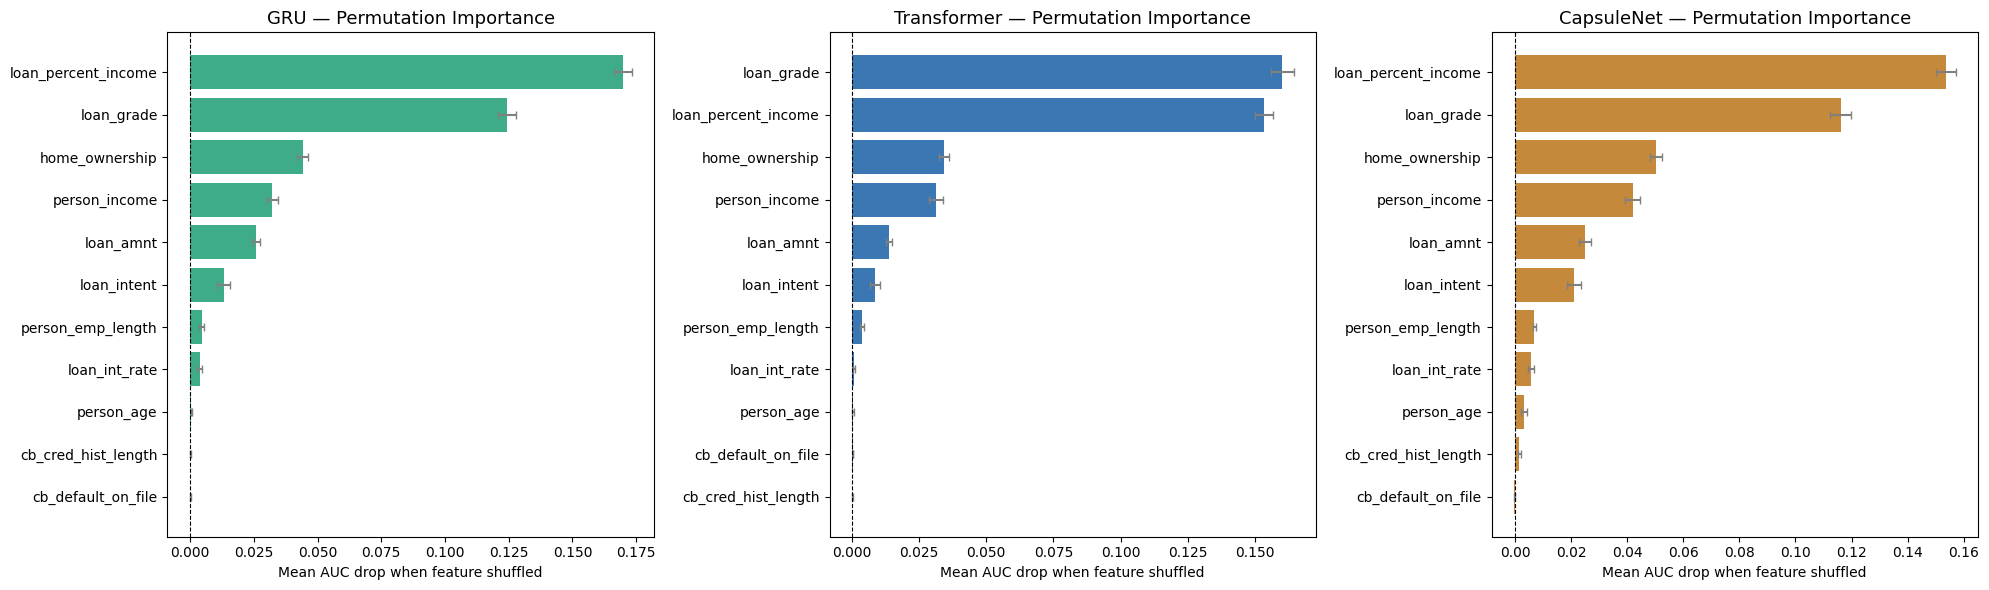

Saved: permutation_importance.png


In [300]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, pi_df, title, color in zip(
    axes,
    [pi_gru, pi_tr, pi_cap],
    ['GRU', 'Transformer', 'CapsuleNet'],
    ['#1d9e75', '#185fa5', '#ba7517']
):
    ax.barh(
        pi_df['feature'],
        pi_df['mean_drop'],
        xerr=pi_df['std_drop'],
        color=color, alpha=0.85,
        error_kw=dict(ecolor='gray', capsize=3)
    )
    ax.set_title(f'{title} — Permutation Importance', fontsize=13)
    ax.set_xlabel('Mean AUC drop when feature shuffled', fontsize=10)
    ax.invert_yaxis()
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: permutation_importance.png")

Part C: Print Summary Ranking Table

In [301]:
print("\n===== PERMUTATION IMPORTANCE RANKINGS =====\n")

for name, pi_df in [('GRU', pi_gru),
                     ('Transformer', pi_tr),
                     ('CapsuleNet', pi_cap)]:
    print(f"--- {name} ---")
    for rank, row in pi_df.iterrows():
        print(f"  #{rank+1:2d}  {row['feature']:30s}  "
              f"AUC drop: {row['mean_drop']:.4f} "
              f"(±{row['std_drop']:.4f})")
    print()


===== PERMUTATION IMPORTANCE RANKINGS =====

--- GRU ---
  # 1  loan_percent_income             AUC drop: 0.1697 (±0.0035)
  # 2  loan_grade                      AUC drop: 0.1243 (±0.0036)
  # 3  home_ownership                  AUC drop: 0.0443 (±0.0022)
  # 4  person_income                   AUC drop: 0.0323 (±0.0021)
  # 5  loan_amnt                       AUC drop: 0.0259 (±0.0017)
  # 6  loan_intent                     AUC drop: 0.0133 (±0.0025)
  # 7  person_emp_length               AUC drop: 0.0046 (±0.0010)
  # 8  loan_int_rate                   AUC drop: 0.0037 (±0.0009)
  # 9  person_age                      AUC drop: 0.0005 (±0.0003)
  #10  cb_cred_hist_length             AUC drop: 0.0002 (±0.0002)
  #11  cb_default_on_file              AUC drop: 0.0000 (±0.0002)

--- Transformer ---
  # 1  loan_grade                      AUC drop: 0.1601 (±0.0043)
  # 2  loan_percent_income             AUC drop: 0.1534 (±0.0034)
  # 3  home_ownership                  AUC drop: 0.0344 (±0.001

Part D: Compare Permutation vs SHAP Rankings

In [302]:
# Build comparison table for each model
def compare_rankings(pi_df, shap_mean_abs, feature_names, model_name):
    shap_ranks = np.argsort(np.abs(shap_mean_abs).mean(axis=0))[::-1]
    shap_rank_dict = {feature_names[i]: r+1
                      for r, i in enumerate(shap_ranks)}

    print(f"\n===== {model_name} — SHAP vs Permutation =====")
    print(f"{'Feature':<28} {'SHAP Rank':>10} {'Perm Rank':>10} {'Match?':>8}")
    print("-" * 60)

    for perm_rank, row in pi_df.iterrows():
        fname      = row['feature']
        shap_rank  = shap_rank_dict.get(fname, '?')
        match      = "✅" if abs(shap_rank - (perm_rank+1)) <= 2 else "❌"
        print(f"{fname:<28} {shap_rank:>10} {perm_rank+1:>10} {match:>8}")

# ── Run comparison ────────────────────────────────────────────
compare_rankings(pi_gru,  shap_gru,  feature_names_list, 'GRU')
compare_rankings(pi_tr,   shap_tr,   feature_names_list, 'Transformer')
compare_rankings(pi_cap,  shap_cap,  feature_names_list, 'CapsuleNet')


===== GRU — SHAP vs Permutation =====
Feature                       SHAP Rank  Perm Rank   Match?
------------------------------------------------------------
loan_percent_income                   1          1        ✅
loan_grade                            2          2        ✅
home_ownership                        6          3        ❌
person_income                         4          4        ✅
loan_amnt                             3          5        ✅
loan_intent                           5          6        ✅
person_emp_length                     8          7        ✅
loan_int_rate                         7          8        ✅
person_age                           10          9        ✅
cb_cred_hist_length                  11         10        ✅
cb_default_on_file                    9         11        ✅

===== Transformer — SHAP vs Permutation =====
Feature                       SHAP Rank  Perm Rank   Match?
------------------------------------------------------------
loan_grade  

Step 14: Final Comparison & Summary

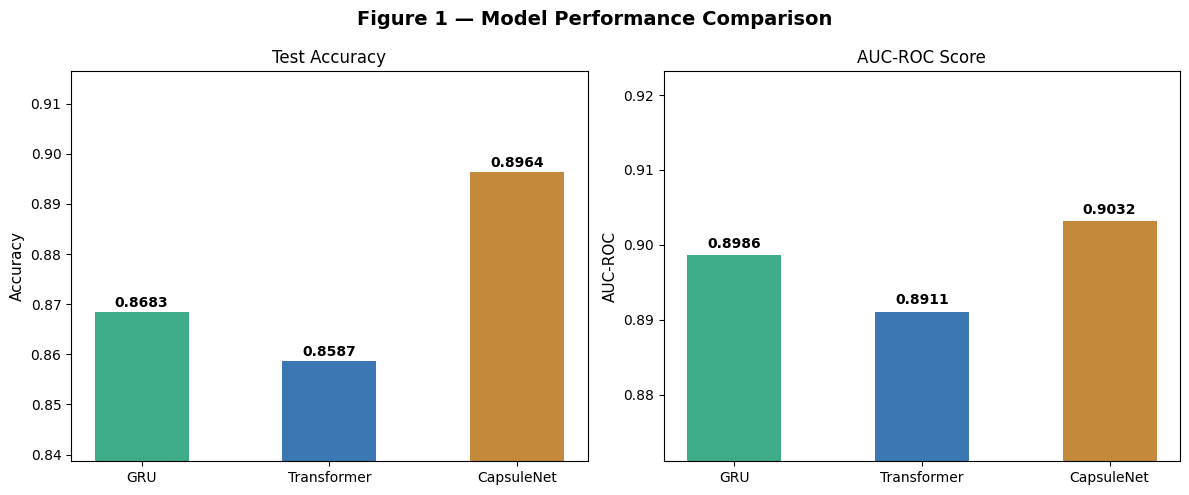

Saved: fig1_model_performance.png

GRU       → Accuracy: 0.8683 | AUC: 0.8986
Transformer → Accuracy: 0.8587 | AUC: 0.8911
CapsuleNet  → Accuracy: 0.8964 | AUC: 0.9032


In [303]:
# ════════════════════════════════════════════════════════════
# FIGURE 1: Model Performance Comparison — Auto computed
# ════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

# ── Auto compute metrics ──────────────────────────────────────
def compute_metrics(model, X_input, y_true):
    probs = model.predict(X_input, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)
    acc   = accuracy_score(y_true, preds)
    auc   = roc_auc_score(y_true, probs)
    return acc, auc

gru_acc,  gru_auc  = compute_metrics(gru_model,        X_test_seq, y_test)
tr_acc,   tr_auc   = compute_metrics(transformer_model, X_test_seq, y_test)
caps_acc, caps_auc = compute_metrics(capsnet_model,     X_test_seq, y_test)

models     = ['GRU', 'Transformer', 'CapsuleNet']
accuracies = [gru_acc,  tr_acc,  caps_acc]
aucs       = [gru_auc,  tr_auc,  caps_auc]
colors     = ['#1d9e75', '#185fa5', '#ba7517']

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 1 — Model Performance Comparison',
             fontsize=14, fontweight='bold')

# Accuracy
axes[0].bar(models, accuracies, color=colors, alpha=0.85, width=0.5)
axes[0].set_ylim(min(accuracies) - 0.02, max(accuracies) + 0.02)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Test Accuracy', fontsize=12)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.001, f'{v:.4f}',
                 ha='center', fontsize=10, fontweight='bold')

# AUC
axes[1].bar(models, aucs, color=colors, alpha=0.85, width=0.5)
axes[1].set_ylim(min(aucs) - 0.02, max(aucs) + 0.02)
axes[1].set_ylabel('AUC-ROC', fontsize=11)
axes[1].set_title('AUC-ROC Score', fontsize=12)
for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.001, f'{v:.4f}',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_model_performance.png")
print(f"\nGRU       → Accuracy: {gru_acc:.4f} | AUC: {gru_auc:.4f}")
print(f"Transformer → Accuracy: {tr_acc:.4f} | AUC: {tr_auc:.4f}")
print(f"CapsuleNet  → Accuracy: {caps_acc:.4f} | AUC: {caps_auc:.4f}")

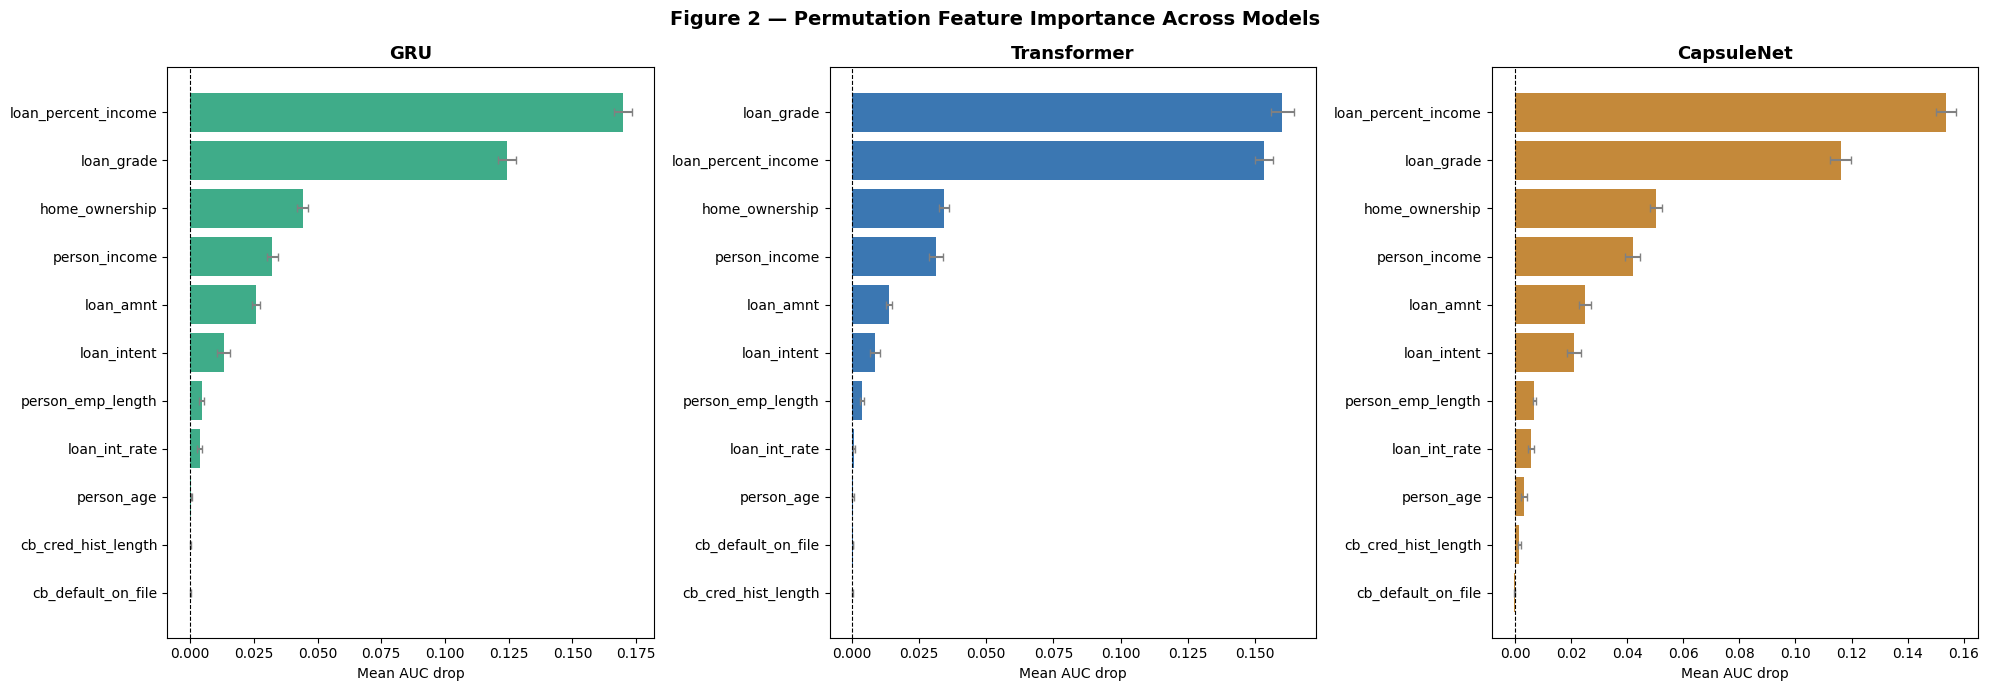

Saved: fig2_permutation_importance.png


In [304]:
# ════════════════════════════════════════════════════════════
# FIGURE 2: Permutation Importance — All 3 Models Side by Side
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Figure 2 — Permutation Feature Importance Across Models',
             fontsize=14, fontweight='bold')

for ax, pi_df, title, color in zip(
    axes,
    [pi_gru, pi_tr, pi_cap],
    ['GRU', 'Transformer', 'CapsuleNet'],
    colors
):
    ax.barh(pi_df['feature'], pi_df['mean_drop'],
            xerr=pi_df['std_drop'], color=color, alpha=0.85,
            error_kw=dict(ecolor='gray', capsize=3))
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Mean AUC drop', fontsize=10)
    ax.invert_yaxis()
    ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('fig2_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_permutation_importance.png")

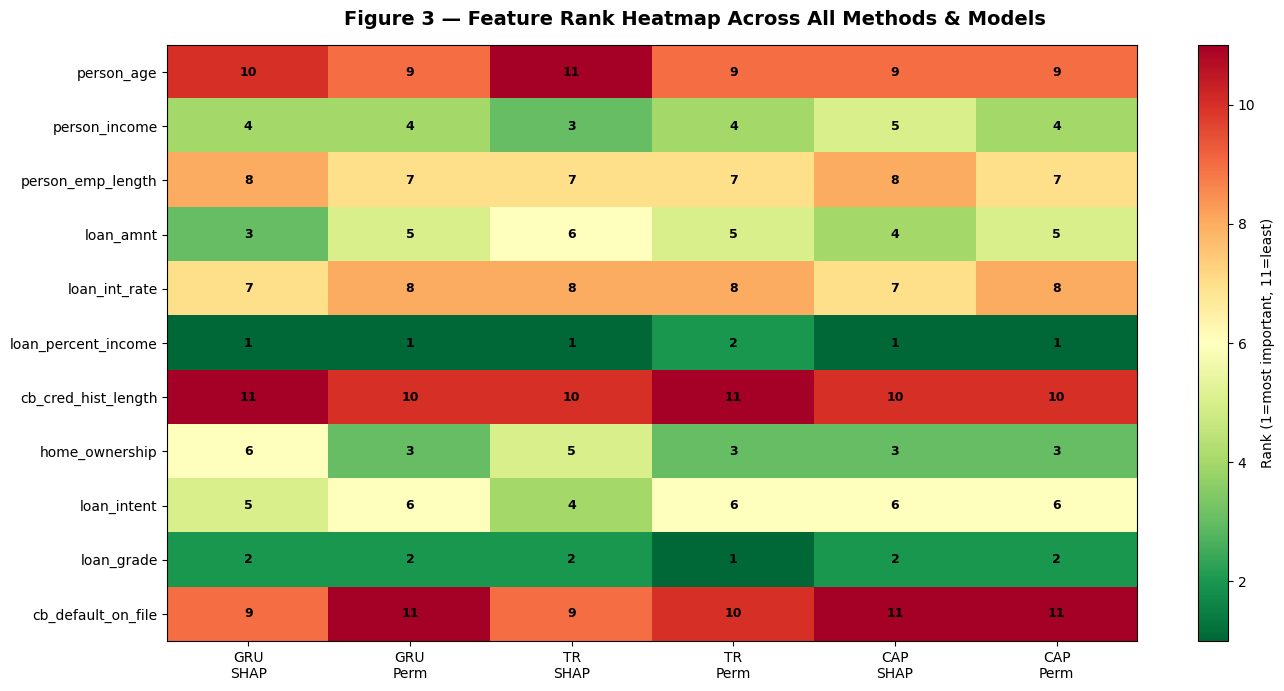

Saved: fig3_rank_heatmap.png


In [305]:
# ════════════════════════════════════════════════════════════
# FIGURE 3: Feature Rank Heatmap — Auto computed from results
# ════════════════════════════════════════════════════════════
from scipy.stats import rankdata
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

feature_names_list = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_cred_hist_length', 'home_ownership', 'loan_intent',
    'loan_grade', 'cb_default_on_file'
]

# ── Auto compute SHAP ranks from actual results ───────────────
gru_shap_ranks_h  = rankdata(-np.abs(shap_gru).mean(axis=0)).astype(int)
tr_shap_ranks_h   = rankdata(-np.abs(shap_tr).mean(axis=0)).astype(int)
caps_shap_ranks_h = rankdata(-np.abs(shap_cap).mean(axis=0)).astype(int)

# ── Auto compute Permutation ranks from actual results ────────
def get_perm_ranks_ordered(pi_df, feature_order):
    pi_idx = pi_df.set_index('feature')
    drops  = np.array([pi_idx.loc[f, 'mean_drop'] for f in feature_order])
    return rankdata(-drops).astype(int)

gru_perm_ranks_h  = get_perm_ranks_ordered(pi_gru,  feature_names_list)
tr_perm_ranks_h   = get_perm_ranks_ordered(pi_tr,   feature_names_list)
caps_perm_ranks_h = get_perm_ranks_ordered(pi_cap,  feature_names_list)

# ── Build rank dataframe ──────────────────────────────────────
rank_df = pd.DataFrame({
    'GRU\nSHAP':  gru_shap_ranks_h,
    'GRU\nPerm':  gru_perm_ranks_h,
    'TR\nSHAP':   tr_shap_ranks_h,
    'TR\nPerm':   tr_perm_ranks_h,
    'CAP\nSHAP':  caps_shap_ranks_h,
    'CAP\nPerm':  caps_perm_ranks_h,
}, index=feature_names_list)

rank_matrix = rank_df.values
col_labels  = list(rank_df.columns)

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('Figure 3 — Feature Rank Heatmap Across All Methods & Models',
             fontsize=14, fontweight='bold')

im = ax.imshow(rank_matrix, cmap='RdYlGn_r', aspect='auto',
               vmin=1, vmax=11)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticks(range(len(feature_names_list)))
ax.set_yticklabels(feature_names_list, fontsize=10)

for i in range(len(feature_names_list)):
    for j in range(len(col_labels)):
        ax.text(j, i, str(rank_matrix[i, j]),
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='black')

plt.colorbar(im, ax=ax, label='Rank (1=most important, 11=least)')
plt.tight_layout()
plt.savefig('fig3_rank_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig3_rank_heatmap.png")

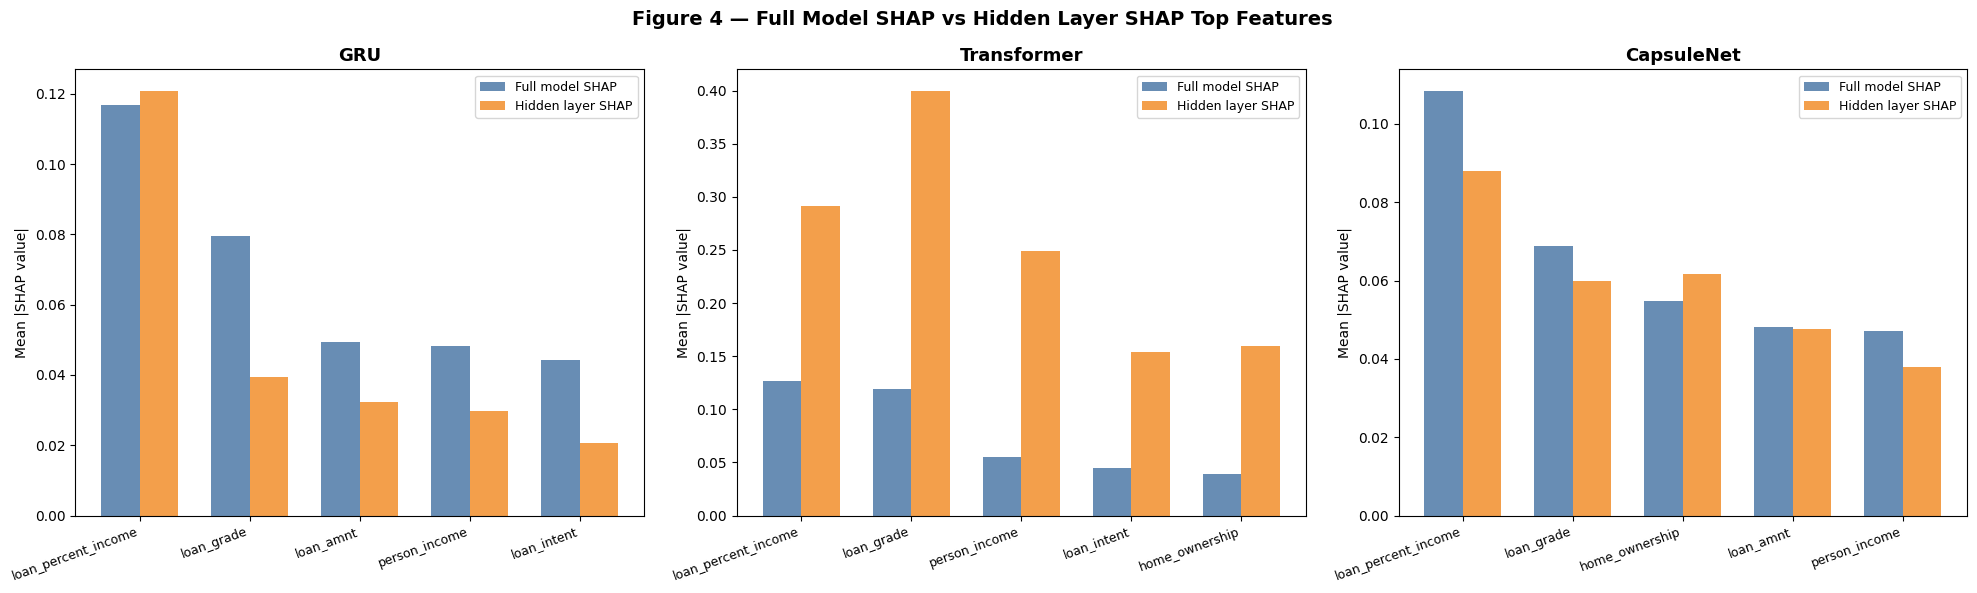

Saved: fig4_hidden_vs_output_shap.png


In [306]:
# ════════════════════════════════════════════════════════════
# FIGURE 4: Hidden vs Output SHAP — Auto computed from results
# ════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt

feature_names_list = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_cred_hist_length', 'home_ownership', 'loan_intent',
    'loan_grade', 'cb_default_on_file'
]

# ── Full model SHAP importance per feature ────────────────────
gru_full_imp  = np.abs(shap_gru).mean(axis=0)   # (11,)
tr_full_imp   = np.abs(shap_tr).mean(axis=0)    # (11,)
caps_full_imp = np.abs(shap_cap).mean(axis=0)   # (11,)

# ── Hidden layer SHAP importance — average across top 6 neurons
gru_hid_imp  = np.mean([np.abs(v).mean(axis=0)
                for v in gru_neuron_shap.values()], axis=0)   # (11,)
tr_hid_imp   = np.mean([np.abs(v).mean(axis=0)
                for v in tr_neuron_shap.values()], axis=0)    # (11,)
caps_hid_imp = np.mean([np.abs(v).mean(axis=0)
                for v in cap_neuron_shap.values()], axis=0)   # (11,)

# ── Plot ──────────────────────────────────────────────────────
models_list = ['GRU', 'Transformer', 'CapsuleNet']
full_imps   = [gru_full_imp,  tr_full_imp,  caps_full_imp]
hid_imps    = [gru_hid_imp,   tr_hid_imp,   caps_hid_imp]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Figure 4 — Full Model SHAP vs Hidden Layer SHAP Top Features',
             fontsize=14, fontweight='bold')

for ax, model_name, full_imp, hid_imp in zip(
        axes, models_list, full_imps, hid_imps):

    # get top 5 features by full model importance
    top5_idx   = np.argsort(full_imp)[::-1][:5]
    top5_names = [feature_names_list[i] for i in top5_idx]
    top5_full  = full_imp[top5_idx]
    top5_hid   = hid_imp[top5_idx]

    x     = np.arange(5)
    width = 0.35

    ax.bar(x - width/2, top5_full, width,
           label='Full model SHAP',   color='#4e79a7', alpha=0.85)
    ax.bar(x + width/2, top5_hid,  width,
           label='Hidden layer SHAP', color='#f28e2b', alpha=0.85)

    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(top5_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Mean |SHAP value|', fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig4_hidden_vs_output_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_hidden_vs_output_shap.png")

In [307]:
# ════════════════════════════════════════════════════════════
# PRINT FINAL SUMMARY TABLE for report
# ════════════════════════════════════════════════════════════
from sklearn.metrics import f1_score
import numpy as np

# ── Auto compute all metrics ──────────────────────────────────
def get_metrics(model, X_seq, y_true):
    probs = model.predict(X_seq, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)
    acc   = accuracy_score(y_true, preds)
    auc   = roc_auc_score(y_true, probs)
    f1    = f1_score(y_true, preds)
    return acc, auc, f1

gru_acc,  gru_auc,  gru_f1  = get_metrics(gru_model,         X_test_seq, y_test)
tr_acc,   tr_auc,   tr_f1   = get_metrics(transformer_model,  X_test_seq, y_test)
caps_acc, caps_auc, caps_f1 = get_metrics(capsnet_model,      X_test_seq, y_test)

# ── Auto compute top SHAP feature ────────────────────────────
def top_shap_feature(shap_vals, feature_names):
    mean_imp = np.abs(shap_vals).mean(axis=0)
    return feature_names[np.argmax(mean_imp)]

gru_top_shap  = top_shap_feature(shap_gru,  feature_names_list)
tr_top_shap   = top_shap_feature(shap_tr,   feature_names_list)
caps_top_shap = top_shap_feature(shap_cap,  feature_names_list)

# ── Auto compute top permutation feature ─────────────────────
gru_top_perm  = pi_gru.iloc[0]['feature']
tr_top_perm   = pi_tr.iloc[0]['feature']
caps_top_perm = pi_cap.iloc[0]['feature']

# ── Auto compute hidden focus feature ────────────────────────
def top_hidden_feature(neuron_shap_dict, feature_names):
    avg_imp = np.mean([np.abs(v).mean(axis=0)
                       for v in neuron_shap_dict.values()], axis=0)
    return feature_names[np.argmax(avg_imp)]

gru_hidden_focus  = top_hidden_feature(gru_neuron_shap,  feature_names_list)
tr_hidden_focus   = top_hidden_feature(tr_neuron_shap,   feature_names_list)
caps_hidden_focus = top_hidden_feature(cap_neuron_shap,  feature_names_list)

# ── Detect shift ──────────────────────────────────────────────
def shift_label(top_shap, hidden_focus):
    if top_shap == hidden_focus:
        return f"{hidden_focus} (stable)"
    else:
        return f"{hidden_focus} (shift!)"

gru_shift  = shift_label(gru_top_shap,  gru_hidden_focus)
tr_shift   = shift_label(tr_top_shap,   tr_hidden_focus)
caps_shift = shift_label(caps_top_shap, caps_hidden_focus)

# ── Print summary ─────────────────────────────────────────────
print("=" * 90)
print("FINAL SUMMARY — ALL MODELS ALL METHODS")
print("=" * 90)

print(f"\n{'Model':<14} {'Accuracy':>10} {'AUC':>8} {'F1':>8} "
      f"{'Top SHAP':>18} {'Top Perm':>18} {'Hidden Focus':>22}")
print("-" * 100)

summary = [
    ('GRU',         gru_acc,  gru_auc,  gru_f1,
     gru_top_shap,  gru_top_perm,  gru_shift),
    ('Transformer', tr_acc,   tr_auc,   tr_f1,
     tr_top_shap,   tr_top_perm,   tr_shift),
    ('CapsuleNet',  caps_acc, caps_auc, caps_f1,
     caps_top_shap, caps_top_perm, caps_shift),
]

for row in summary:
    print(f"{row[0]:<14} {row[1]:>10.4f} {row[2]:>8.4f} {row[3]:>8.4f} "
          f"{row[4]:>18} {row[5]:>18} {row[6]:>22}")

# ── Auto key findings ─────────────────────────────────────────
print("\n")
print("KEY FINDINGS:")
print("-" * 90)
print(f"1. Accuracy  — GRU: {gru_acc:.4f} | Transformer: {tr_acc:.4f} | CapsuleNet: {caps_acc:.4f}")
print(f"2. AUC       — GRU: {gru_auc:.4f} | Transformer: {tr_auc:.4f} | CapsuleNet: {caps_auc:.4f}")
print(f"3. F1 Score  — GRU: {gru_f1:.4f}  | Transformer: {tr_f1:.4f}  | CapsuleNet: {caps_f1:.4f}")
print(f"4. Top SHAP feature — GRU: {gru_top_shap} | Transformer: {tr_top_shap} | CapsuleNet: {caps_top_shap}")
print(f"5. Hidden focus     — GRU: {gru_hidden_focus} | Transformer: {tr_hidden_focus} | CapsuleNet: {caps_hidden_focus}")
print(f"6. Internal shift   — GRU: {gru_shift} | TR: {tr_shift} | CAP: {caps_shift}")
print("=" * 90)

FINAL SUMMARY — ALL MODELS ALL METHODS

Model            Accuracy      AUC       F1           Top SHAP           Top Perm           Hidden Focus
----------------------------------------------------------------------------------------------------
GRU                0.8683   0.8986   0.7086 loan_percent_income loan_percent_income loan_percent_income (stable)
Transformer        0.8587   0.8911   0.6894 loan_percent_income         loan_grade    loan_grade (shift!)
CapsuleNet         0.8964   0.9032   0.7454 loan_percent_income loan_percent_income loan_percent_income (stable)


KEY FINDINGS:
------------------------------------------------------------------------------------------
1. Accuracy  — GRU: 0.8683 | Transformer: 0.8587 | CapsuleNet: 0.8964
2. AUC       — GRU: 0.8986 | Transformer: 0.8911 | CapsuleNet: 0.9032
3. F1 Score  — GRU: 0.7086  | Transformer: 0.6894  | CapsuleNet: 0.7454
4. Top SHAP feature — GRU: loan_percent_income | Transformer: loan_percent_income | CapsuleNet: loan_pe

In [308]:
# ════════════════════════════════════════════════════════════
# SPEARMAN CORRELATION: Output SHAP vs Hidden Layer SHAP
# ════════════════════════════════════════════════════════════
from scipy.stats import spearmanr
import numpy as np

print("=" * 60)
print("SPEARMAN CORRELATION: Full Model vs Hidden Layer SHAP")
print("=" * 60)

# ── Compute mean abs SHAP per feature for output level ───────
gru_out_importance   = np.abs(shap_gru).mean(axis=0)   # (11,)
tr_out_importance    = np.abs(shap_tr).mean(axis=0)    # (11,)
caps_out_importance  = np.abs(shap_cap).mean(axis=0)   # (11,)

# ── Compute mean abs SHAP per feature for hidden layer ───────
# Average across top 6 neurons → (11,)
gru_hid_importance  = np.mean([np.abs(v).mean(axis=0)
                       for v in gru_neuron_shap.values()], axis=0)
tr_hid_importance   = np.mean([np.abs(v).mean(axis=0)
                       for v in tr_neuron_shap.values()], axis=0)
caps_hid_importance = np.mean([np.abs(v).mean(axis=0)
                       for v in cap_neuron_shap.values()], axis=0)

# ── Compute Spearman for each model ──────────────────────────
for model_name, out_imp, hid_imp in [
    ("GRU",         gru_out_importance,  gru_hid_importance),
    ("Transformer", tr_out_importance,   tr_hid_importance),
    ("CapsuleNet",  caps_out_importance, caps_hid_importance),
]:
    r, p = spearmanr(out_imp, hid_imp)
    print(f"\n{model_name}:")
    print(f"  Spearman r = {r:.3f}")
    print(f"  p-value    = {p:.4f}")
    if r > 0.8:
        print(f"  → Strong agreement: hidden layer mirrors output")
    elif r > 0.5:
        print(f"  → Moderate agreement: some internal shift detected")
    else:
        print(f"  → Weak agreement: significant internal feature shift!")

print("\n" + "=" * 60)
print("Interpretation:")
print("r close to +1.0 = hidden layer and output use same features")
print("r close to  0.0 = hidden layer processes very differently")
print("=" * 60)

SPEARMAN CORRELATION: Full Model vs Hidden Layer SHAP

GRU:
  Spearman r = 0.873
  p-value    = 0.0005
  → Strong agreement: hidden layer mirrors output

Transformer:
  Spearman r = 0.945
  p-value    = 0.0000
  → Strong agreement: hidden layer mirrors output

CapsuleNet:
  Spearman r = 0.982
  p-value    = 0.0000
  → Strong agreement: hidden layer mirrors output

Interpretation:
r close to +1.0 = hidden layer and output use same features
r close to  0.0 = hidden layer processes very differently


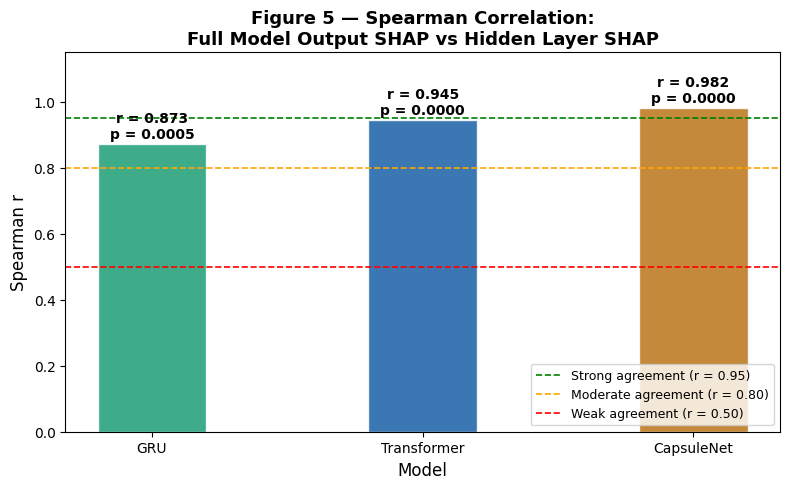

In [309]:
# ════════════════════════════════════════════════════════════
# FIGURE 5 — Spearman Correlation Bar Chart
# ════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

models     = ['GRU', 'Transformer', 'CapsuleNet']
spearman_r = [
    spearmanr(gru_out_importance,  gru_hid_importance)[0],
    spearmanr(tr_out_importance,   tr_hid_importance)[0],
    spearmanr(caps_out_importance, caps_hid_importance)[0]
]
p_values = [
    spearmanr(gru_out_importance,  gru_hid_importance)[1],
    spearmanr(tr_out_importance,   tr_hid_importance)[1],
    spearmanr(caps_out_importance, caps_hid_importance)[1]
]
colors = ['#1d9e75', '#185fa5', '#ba7517']

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(models, spearman_r, color=colors,
              width=0.4, alpha=0.85, edgecolor='white')

# threshold lines
ax.axhline(0.95, color='green',  linestyle='--',
           linewidth=1.2, label='Strong agreement (r = 0.95)')
ax.axhline(0.80, color='orange', linestyle='--',
           linewidth=1.2, label='Moderate agreement (r = 0.80)')
ax.axhline(0.50, color='red',    linestyle='--',
           linewidth=1.2, label='Weak agreement (r = 0.50)')

# value labels on top of each bar
for bar, r_val, p_val in zip(bars, spearman_r, p_values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'r = {r_val:.3f}\np = {p_val:.4f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Spearman r', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Figure 5 — Spearman Correlation:\nFull Model Output SHAP vs Hidden Layer SHAP',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('fig5_spearman_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

SHAP vs Permutation Importance (per model)

SPEARMAN: SHAP vs Permutation Importance
GRU            : r = 0.900,  p = 0.0002
Transformer    : r = 0.918,  p = 0.0001
CapsuleNet     : r = 0.982,  p = 0.0000


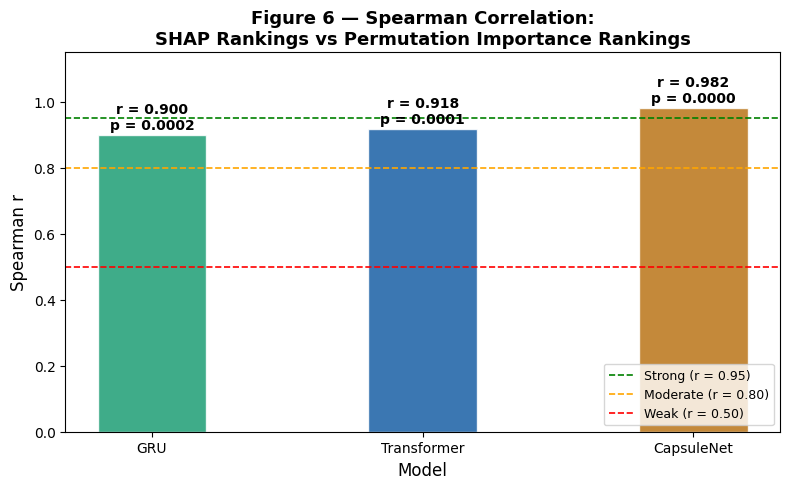

In [310]:
# ════════════════════════════════════════════════════════════
# FIGURE 6 — Spearman: SHAP vs Permutation per model
# ════════════════════════════════════════════════════════════
from scipy.stats import spearmanr, rankdata
import matplotlib.pyplot as plt
import numpy as np

feature_names_list = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_cred_hist_length', 'home_ownership', 'loan_intent',
    'loan_grade', 'cb_default_on_file'
]

# ── SHAP importance in original feature order ─────────────────
gru_shap_imp  = np.abs(shap_gru).mean(axis=0)
tr_shap_imp   = np.abs(shap_tr).mean(axis=0)
caps_shap_imp = np.abs(shap_cap).mean(axis=0)

gru_shap_ranks  = rankdata(-gru_shap_imp).astype(int)
tr_shap_ranks   = rankdata(-tr_shap_imp).astype(int)
caps_shap_ranks = rankdata(-caps_shap_imp).astype(int)

# ── Permutation importance in original feature order ──────────
def get_perm_ranks(pi_df, feature_order):
    pi_idx = pi_df.set_index('feature')
    drops  = np.array([pi_idx.loc[f, 'mean_drop']
                        for f in feature_order])
    return rankdata(-drops).astype(int)

gru_perm_ranks  = get_perm_ranks(pi_gru,  feature_names_list)
tr_perm_ranks   = get_perm_ranks(pi_tr,   feature_names_list)
caps_perm_ranks = get_perm_ranks(pi_cap,  feature_names_list)

# ── Compute Spearman ──────────────────────────────────────────
models = ['GRU', 'Transformer', 'CapsuleNet']

r_vals = [
    spearmanr(gru_shap_ranks,  gru_perm_ranks)[0],
    spearmanr(tr_shap_ranks,   tr_perm_ranks)[0],
    spearmanr(caps_shap_ranks, caps_perm_ranks)[0]
]
p_vals = [
    spearmanr(gru_shap_ranks,  gru_perm_ranks)[1],
    spearmanr(tr_shap_ranks,   tr_perm_ranks)[1],
    spearmanr(caps_shap_ranks, caps_perm_ranks)[1]
]

# ── Print ─────────────────────────────────────────────────────
print("=" * 55)
print("SPEARMAN: SHAP vs Permutation Importance")
print("=" * 55)
for m, r, p in zip(models, r_vals, p_vals):
    print(f"{m:15s}: r = {r:.3f},  p = {p:.4f}")
print("=" * 55)

# ── Plot ──────────────────────────────────────────────────────
colors = ['#1d9e75', '#185fa5', '#ba7517']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r_vals, color=colors,
              width=0.4, alpha=0.85, edgecolor='white')

ax.axhline(0.95, color='green',  linestyle='--',
           linewidth=1.2, label='Strong (r = 0.95)')
ax.axhline(0.80, color='orange', linestyle='--',
           linewidth=1.2, label='Moderate (r = 0.80)')
ax.axhline(0.50, color='red',    linestyle='--',
           linewidth=1.2, label='Weak (r = 0.50)')

for bar, r, p in zip(bars, r_vals, p_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f'r = {r:.3f}\np = {p:.4f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Spearman r', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Figure 6 — Spearman Correlation:\n'
             'SHAP Rankings vs Permutation Importance Rankings',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('fig6_spearman_shap_vs_perm.png',
            dpi=150, bbox_inches='tight')
plt.show()

Option 2 — Cross-Model SHAP Agreement

SPEARMAN: Cross-Model SHAP Agreement
GRU vs Transformer            : r = 0.927,  p = 0.0000
GRU vs CapsuleNet             : r = 0.918,  p = 0.0001
Transformer vs CapsuleNet     : r = 0.882,  p = 0.0003


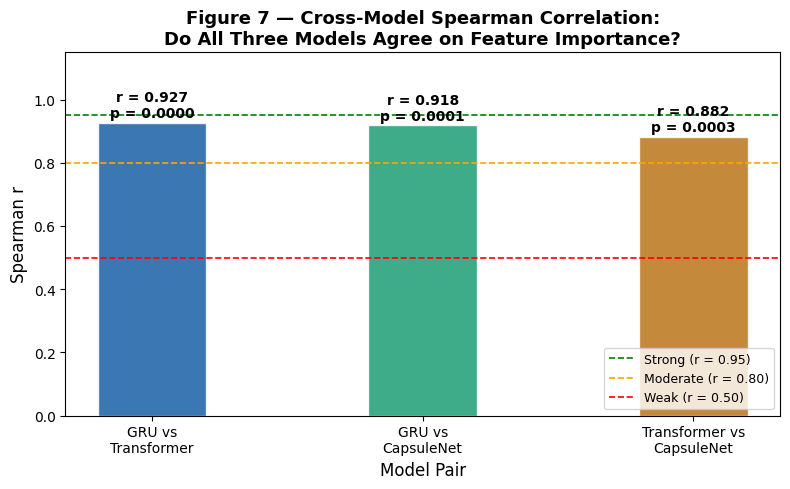

In [311]:
# ════════════════════════════════════════════════════════════
# FIGURE 7 — Spearman: Cross-model SHAP agreement
# ════════════════════════════════════════════════════════════
from scipy.stats import spearmanr, rankdata
import matplotlib.pyplot as plt
import numpy as np

# ── SHAP ranks already computed above ────────────────────────
# gru_shap_ranks, tr_shap_ranks, caps_shap_ranks
# If running this cell standalone recompute:
gru_shap_ranks  = rankdata(-np.abs(shap_gru).mean(axis=0)).astype(int)
tr_shap_ranks   = rankdata(-np.abs(shap_tr).mean(axis=0)).astype(int)
caps_shap_ranks = rankdata(-np.abs(shap_cap).mean(axis=0)).astype(int)

# ── Three model pairs ─────────────────────────────────────────
pairs = [
    ('GRU vs\nTransformer',  gru_shap_ranks,  tr_shap_ranks),
    ('GRU vs\nCapsuleNet',   gru_shap_ranks,  caps_shap_ranks),
    ('Transformer vs\nCapsuleNet', tr_shap_ranks, caps_shap_ranks)
]

r_vals = [spearmanr(a, b)[0] for _, a, b in pairs]
p_vals = [spearmanr(a, b)[1] for _, a, b in pairs]
labels = [p[0] for p in pairs]

# ── Print ─────────────────────────────────────────────────────
print("=" * 55)
print("SPEARMAN: Cross-Model SHAP Agreement")
print("=" * 55)
for label, r, p in zip(labels, r_vals, p_vals):
    clean = label.replace('\n', ' ')
    print(f"{clean:30s}: r = {r:.3f},  p = {p:.4f}")
print("=" * 55)

# ── Plot ──────────────────────────────────────────────────────
colors = ['#185fa5', '#1d9e75', '#ba7517']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, r_vals, color=colors,
              width=0.4, alpha=0.85, edgecolor='white')

ax.axhline(0.95, color='green',  linestyle='--',
           linewidth=1.2, label='Strong (r = 0.95)')
ax.axhline(0.80, color='orange', linestyle='--',
           linewidth=1.2, label='Moderate (r = 0.80)')
ax.axhline(0.50, color='red',    linestyle='--',
           linewidth=1.2, label='Weak (r = 0.50)')

for bar, r, p in zip(bars, r_vals, p_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f'r = {r:.3f}\np = {p:.4f}',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Spearman r', fontsize=12)
ax.set_xlabel('Model Pair', fontsize=12)
ax.set_title('Figure 7 — Cross-Model Spearman Correlation:\n'
             'Do All Three Models Agree on Feature Importance?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('fig7_spearman_cross_model.png',
            dpi=150, bbox_inches='tight')
plt.show()